In [1]:
import pandas as pd 
from matplotlib import pyplot as plt
from sklearn.model_selection import TimeSeriesSplit
import numpy as np

### Step 1: Load the data + scoped the data

In [2]:
filename = 'paysim_transactions.csv.gz' 

In [3]:
# load the file into a DataFrame 
df = pd.read_csv(filename)

# check it its size 
print (df.shape)

# check  column types 
print (df.info())

(3410988, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3410988 entries, 0 to 3410987
Data columns (total 12 columns):
 #   Column                   Dtype  
---  ------                   -----  
 0   step                     int64  
 1   action                   object 
 2   amount                   float64
 3   nameOrig                 object 
 4   oldBalanceOrig           float64
 5   newBalanceOrig           float64
 6   nameDest                 object 
 7   oldBalanceDest           float64
 8   newBalanceDest           float64
 9   isFraud                  int64  
 10  isFlaggedFraud           int64  
 11  isUnauthorizedOverdraft  int64  
dtypes: float64(5), int64(4), object(3)
memory usage: 312.3+ MB
None


In [4]:
length = df.shape[0]

In [5]:
# Find the fraud rate 
print(df['isFraud'].value_counts())

print(df['isFraud'].value_counts(normalize=True))
# 1 = fraud; 0 = notFraud 

isFraud
0    3409620
1       1368
Name: count, dtype: int64
isFraud
0    0.999599
1    0.000401
Name: proportion, dtype: float64


In [6]:
fraud_rate = df['isFraud'].value_counts(normalize=True)[1]
print (fraud_rate)

0.00040105681990086156


In [8]:
# lets find where fraud happens 

pd.crosstab(df['action'], df['isFraud'])

# Fraud only happens only when action is either CASH_OUT or TRANSFER, so lets filter to those types 

isFraud,0,1
action,,
CASH_IN,1472338,0
CASH_OUT,799683,684
DEBIT,153014,0
PAYMENT,784963,0
TRANSFER,199622,684


In [9]:
# Apply filter and measure what changed 

fraud_mask = df['action'].isin(['CASH_OUT', 'TRANSFER'])

filtered_df = df[fraud_mask]
filtered_length = (len(filtered_df))

In [10]:
new_fraud_rate = fraud_rate * (length/filtered_length)
print(new_fraud_rate, filtered_length)

# so our set ONLY entails 1M rows and about 0.14% of those are fraud 

0.001367079955190157 1000673


### Step 2: Look for leaky features 
A data leak is when information that wouldn't be available in real use sneaks into my model or evauluation. 


In [11]:
print(filtered_df['isFraud'].value_counts())

print(filtered_df['isFraud'].value_counts(normalize=True))

# the value matches so we are good 

isFraud
0    999305
1      1368
Name: count, dtype: int64
isFraud
0    0.998633
1    0.001367
Name: proportion, dtype: float64


In [12]:
# an account is considered 'drained' if a transaction empties the sender's account completely 

# lets find the drained rows -- this is a boolean mask for it 
drained  = (filtered_df['newBalanceOrig'] == 0 ) & (filtered_df['oldBalanceOrig'] == filtered_df['amount'])

In [13]:
# 1. of the drained transactions, what fractions are fraud?  (precision)

drained_recall = (filtered_df[drained]['isFraud'] == 1).sum() / len(filtered_df[drained])

In [14]:
# 2. of the fraud transactions, what fractions are drained? (recall) 

drained_prec = (filtered_df[drained]['isFraud'] == 1).sum()/ (filtered_df['isFraud'] == 1).sum()

In [15]:
print(drained_recall, drained_prec)

1.0 1.0


In PaySim, an exactly drained sender account identifies fraud with 100% precision and 100% recall. This is a simulation artifact, so balance-based features are excluded from modeling.

In [16]:
# Check the ID leak

In [17]:
# boolean mask for rows in which mule accounts starts with 'CC'
id_mask = df['nameOrig'].str.startswith("CC")

In [18]:

# how man fraudsters has a id_mask that starts with CC ? 
cc_prec = ((id_mask) & (df['isFraud'] == 1)).sum()  /len(df[id_mask])

# of all fraud transactions, what fraction come from a "CC" account
cc_recall = ((id_mask) & (df['isFraud'] == 1)).sum() / (df['isFraud'] == 1).sum()

print (cc_prec, cc_recall) 

1.0 0.5036549707602339


So the ID rule has 100% precision but only about 50% recall. Account IDs starting with 'CC' are simulator-assigned mule accounts.  Account IDs are excluded as model features; they're used only to group transactions by account for velocity features

### 3. Time-based train/test/split 

In [19]:
filtered_df['day'] = df.step//24

/var/folders/rk/888fv3n533n_d0tlr213d9h40000gn/T/ipykernel_80132/3165888416.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df['day'] = df.step//24


<Axes: xlabel='day'>

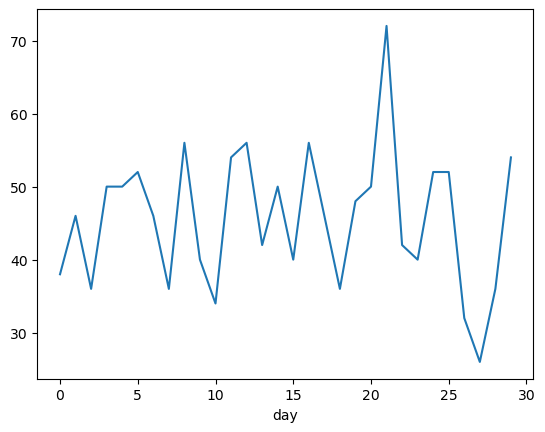

In [23]:
# how many fraud cases happen on each day? -- want one count per day
filtered_df.groupby(by='day')['isFraud'].sum().plot()

### Train/Test Split
The data spans 30 days. I use the first 24 days (80%) for training and hold out the last 6 days (days 24–29) for testing. Splitting by time rather than at random means the model is always evaluated on transactions from after the period it learned from, which is how it would be used in practice.

### Is the test set large enough?  

Fraud occurs at a steady ~45 cases per day, so the test set should contain about 45 × 6 ≈ 270 fraud cases. Each case is worth 1/270 ≈ 0.37% of recall.

Treating each detection as a binomial trial, the uncertainty on recall is roughly $\sqrt{p(1-p)/N}$. For a true recall of 80% and N = 270, that's about ±2.4%.

This is small compared to the differences I want to measure, such as the rules baseline versus the ML model, so those comparisons will be meaningful. Differences smaller than a few percentage points will not be treated as significant.

In [24]:
p = 0.8
N = 270
np.sqrt((p*(1-p))/ N)

np.float64(0.02434322477800738)

In [25]:
# create masks for training and testing data set  
train_mask = filtered_df['day'] < 24
test_mask = filtered_df['day'] >= 24

In [26]:
train = filtered_df[train_mask]
test = filtered_df[test_mask]

In [27]:
len(train) + len(test) , len(filtered_df) # thest values should be the same 

(1000673, 1000673)

In [28]:
# how many fraud cases are there actually in the test set? should be ~270. 
test['isFraud'].sum()

np.int64(252)

In [29]:
np.sqrt(270)
# For a count of 270, the Poisson scatter is about np.sqrt(270) = 16 so 252 is only about one standard deviation below. 

np.float64(16.431676725154983)

In [30]:
train.groupby(by=['action', 'isFraud'])['amount'].describe()

count          mean           std    min           25%  \
action   isFraud                                                              
CASH_OUT 0        791301.0  1.265754e+05  6.284630e+04   1.99  8.067517e+04   
         1           558.0  3.906533e+06  2.347440e+06  22.50  2.604452e+06   
TRANSFER 0        197746.0  8.862934e+05  9.626819e+05   4.48  3.107283e+05   
         1           558.0  3.906533e+06  2.347440e+06  22.50  2.604452e+06   

                          50%         75%          max  
action   isFraud                                        
CASH_OUT 0         123308.750   168042.43    508265.84  
         1        3483490.780  4638746.69  14802308.80  
TRANSFER 0         600527.115  1109194.22  17684052.98  
         1        3483490.780  4638746.69  14802308.80

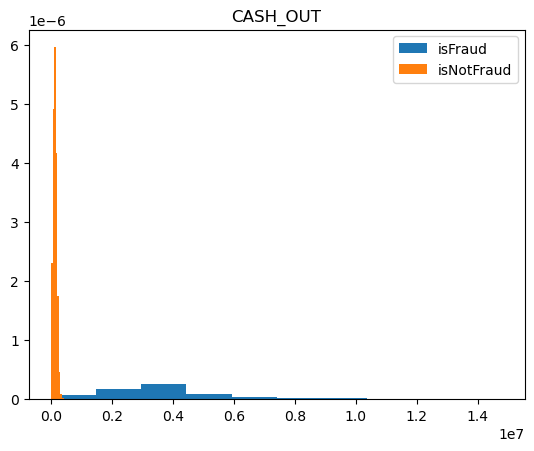

In [31]:
cashout = train[train['action'] == 'CASH_OUT']

cashout_isFraud = cashout[cashout['isFraud'] == 1] 
cashout_isNotFraud = cashout[cashout['isFraud'] == 0]

fig, ax = plt.subplots()
ax.hist(cashout_isFraud['amount'], density= True, label = 'isFraud')
ax.hist(cashout_isNotFraud['amount'], density= True, label = 'isNotFraud')
ax.legend()
ax.set_title("CASH_OUT")
#ax.set_yscale('log') 
#ax.set_xscale('log') 
plt.show()

508k is the max for non-fraud for cashout -- should that be the threshold? 

In [32]:
### how many fraud cases in the cashout group in which the amount is between 508k and 1 million?

((cashout[cashout['isFraud'] == 1]['amount'] <1000000) & (cashout[cashout['isFraud'] == 1]['amount'] > 508000)).sum()

np.int64(13)

In [33]:
# how many total fraud cases are there ? 
len(cashout[cashout['isFraud'] == 1])

558

In [34]:
13/558

0.023297491039426525

The $508K$ threshold gains about 2\% more cash-out fraud in training than $1M. This is a small difference, below what the test set can reliably detect.

In [35]:
transfer = train[train['action'] == 'TRANSFER']

transfer_isFraud = transfer[transfer['isFraud'] == 1] 
transfer_isNotFraud = transfer[transfer['isFraud'] == 0]

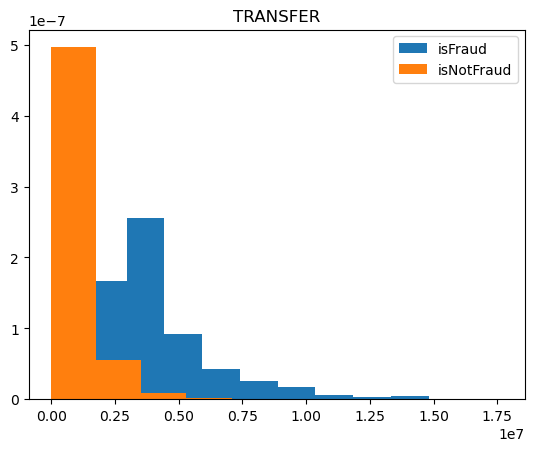

In [36]:
fig, ax = plt.subplots()
ax.hist(transfer_isFraud['amount'], density= True, label = 'isFraud')
ax.hist(transfer_isNotFraud['amount'], density= True, label = 'isNotFraud')
ax.legend()
ax.set_title("TRANSFER")
#ax.set_yscale('log') 
#ax.set_xscale('log') 
plt.show()

In [37]:
# how many legitimate transfers would be flagged? 

# Flagged but legitimate 
flagged_but_legit = (transfer[transfer['isFraud'] == 0]['amount'] > 2600000).sum()

In [38]:
flagged_but_legit/len(transfer[transfer['isFraud'] == 0])

np.float64(0.0519504819313665)

About 5% of legtitatme transfers would be flagged -- which seems small but, the TRANSFER rule flags 418 fraud transfers and about 10,273 legitimate transfers 

In [39]:
# of everything that the rule flags, what fraction is actually fraud (precision) 

# Flagged and ACTUALLY fraud 
flagged_and_fraud =  (transfer[transfer['isFraud'] == 1]['amount'] > 2600000).sum() 

In [40]:
total_flagged = flagged_and_fraud + flagged_but_legit

precision = (flagged_and_fraud) / total_flagged
print (precision)

0.039098306987185485


so only about 1 in 26 flagged transfers is a real fraud. 

Lets keep 2.6M as the threshold. It catches 75% of fraud transfers with poor precision. 


### Rules baseline: 
- CASH_OUT: flag if amount is > $508K
  
- TRANSFER: flag if amount is > $2.6M

These were chosen using ONLY the training data set. 

In [41]:
# lets now do this for the testing dataset 

rules_mask =  (test['action'] == 'CASH_OUT') & (test['amount'] > 508000) |  (test['action'] == 'TRANSFER') & (test['amount'] > 2600000)

In [42]:
# recall: of all fraud in the test set, what fraction did the rules flag? 

# flagged AND fraud 
flagged_and_fraud = ((rules_mask)  & (test['isFraud'] == 1)).sum()

recall = flagged_and_fraud / (test['isFraud'] == 1).sum()

print (recall)

#############################

# precision: of everything flagged, what fraction is fraud? 
flagged_total = len(test[rules_mask])


precision = flagged_and_fraud / flagged_total

print (precision)

0.9603174603174603
0.7908496732026143


In [43]:
(test['isFraud'] == 1).sum()/len(test)

np.float64(0.023977164605137963)

In [44]:
(train['isFraud'] == 1).sum()/len(train)

np.float64(0.0011270871563570845)

<Axes: xlabel='day'>

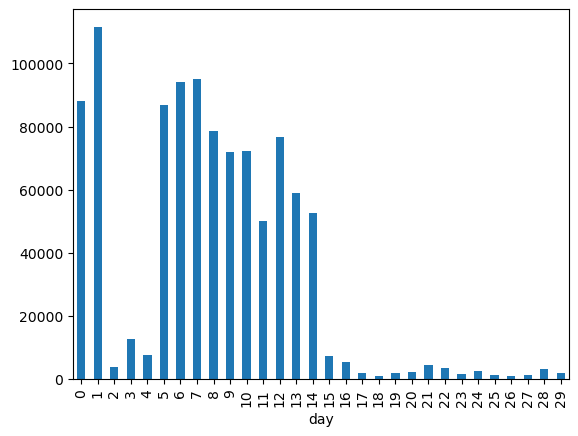

In [45]:

filtered_df.groupby(by='day').size().plot(kind='bar')


In [46]:
# we see here that at the end of the month, the activity is much lower! 

## let compute the false positive rate for BOTH training and testing data set 

FPR = (legit_and_flagged) / (legit)



In [47]:
# testing 

test_fpr = ((rules_mask) & (test['isFraud'] == 0 )).sum() / (test['isFraud'] == 0).sum()
print (test_fpr)

0.006239032949892766


In [52]:
# training 

train_rules_mask = (train['action'] == 'CASH_OUT') & (train['amount'] > 508000) |  (train['action'] == 'TRANSFER') & (train['amount'] > 2600000)
train_fpr =  ((train_rules_mask) & (train['isFraud'] == 0 )).sum() / (train['isFraud'] == 0).sum()

train_recall =  ((train_rules_mask) & (train['isFraud'] == 1)).sum() / (train['isFraud'] == 1).sum()
train_prec =   ((train_rules_mask) & (train['isFraud'] == 1)).sum() / (train_rules_mask).sum()

print (train_fpr)
print (train_recall)
print (train_prec)

0.010387777325041175
0.8494623655913979
0.08447692033505615


In [50]:
number_of_transcations = 1000000
base_rate = 0.0011
recall = 0.96
fpr = 0.0062 

# 1. how many are fraud 
f = base_rate * number_of_transcations
print (f)
# 2. how many are legitimate 
l = number_of_transcations - f
print (l)
# 3. how many frauds do the rules catch 
catch = recall * f 
print(catch)
# 4. how many false alarms (fpr x number of legit)
fa = fpr * l 
print (fa)
# 5. precision = caught / (caught + fa)
p = catch / (catch + fa)
print (p)

1100.0
998900.0
1056.0
6193.179999999999
0.14567164837954086


The dataset was split with days 0-23 as the training data set, and days 24-29 as the testing data set. Since legitimate activity drops sharply late in the month, the test set contains far fewer than 20% of the transactions, but fraud continues at a steady ~45 cases per day, so the test set's fraud rate is much higher. 

Using the training set only, I compared the CASH_OUT and TRANSFER as those were the only actions in which fraud occurs. After taking a look at those distributions and comparing them with non-fraud distributions for those same actions:

- CASH_OUT: $508K is just above the largest legitimate cash-out so there are no false alarms in training
  
- TRANSFER: $2.6M is the fraud 25th percentile, so it catches about 75% of fraud transfers, accepting some false alarms because the distributions overlap

On the test set, these rules achieved 96% recall (85% on train) with a 0.62% false positive rate. The recall is higher on the test dataset because the test periods fraud involved larger amounts (median $4.1M vs. $3.5M), so more fraud transfers cleared the $2.6M threshold. 

The precision jumped from 8.4% (train) to 79% (test) because the fraud rate jumped from 0.11% to 2.4%. At the normal rate of 0.11%, the estimated precision is about 8-15%: 8.4% measured directly on train, and ~15% estimated by applying the test set's recall and false positive rate to 1M transactions at the training fraud rate. 

The false positive rate is a little lower in the test data set than in the training data set (0.62% vs 1.04%) because the last six days were quieter, with fewer large legitimate transfers that trigger the $2.6M rule. 

Amount alone cannot separate fraud transfers from large legitimate ones. This is the main weakness of the rules baseline, and what the ML model should improve on.